# New Project Testbench


Project Sturcture
- Reproduce Lia's work -> code at...
- Structurize e.g.
  - query
  - reformatting
  - saving
  - merging
  - expand

## Lia's work

### open questions
- is the way we get to the radius right?
    - e.g. should in addition the distance be taken into account? 50 as at 50 pc is about 0.7pc (150kAU)
    - starcat vs hpic radius, where does the difference come from?
    - should we stack the catalogs first before determining the radius?

In [1]:
from utils.io import load
[HPIC_StarCat,starcat5_not_in_hpic,pre_merge_hpic] = load(["HPIC_StarCat","starcat5_not_in_hpic","pre_merge_hpic"],location="../../../../additional_data/")

### imports

In [1]:
from utils.io import save
from catalog.starcat5_merger.fcts_cat_merge import get_mask_cat2_in_cat1, nearest_neighbor_distances_units

### load catalogs

In [10]:
print(hpic)
print(hpic.colnames)

         star_name                ra     ... sy_planets_flag hostname
---------------------------- ----------- ... --------------- --------
               TIC 459832522  213.915338 ...               0     null
               TIC 245873777   68.980213 ...               1  alf Tau
               TIC 272314138  187.791407 ...               0     null
               TIC 322899250  101.286998 ...               0     null
               TIC 368326352   79.172437 ...               0     null
               TIC 471011144  219.903981 ...               0     null
               TIC 280310048  114.825217 ...               0     null
               TIC 471011145  219.910043 ...               0     null
               TIC 157587146  279.234764 ...               0     null
               TIC 423088367  116.328966 ...               1 HD 62509
                         ...         ... ...             ...      ...
GAIA DR3 6742328107524142976 289.8782682 ...               0     null
GAIA DR3 67455736596

In [113]:
print(hpic["star_name","known_binary_fl"])

         star_name           known_binary_fl
---------------------------- ---------------
               TIC 459832522               1
               TIC 245873777               1
               TIC 272314138               1
               TIC 322899250               1
               TIC 368326352               1
               TIC 471011144               1
               TIC 280310048               1
               TIC 471011145               1
               TIC 157587146               1
               TIC 423088367               1
                         ...             ...
GAIA DR3 6742328107524142976               1
GAIA DR3 6745573659695679616               1
GAIA DR3 6792808541781612800               0
GAIA DR3 6823750688771587840               0
GAIA DR3 6827751124390424320               0
GAIA DR3 6832480291404495360               0
GAIA DR3 6833291426043854976               0
GAIA DR3 6896057214818851712               1
GAIA DR3 6910053108781758976               0
GAIA DR3 6

In [4]:
print(StarCat5_50pc.colnames)

['main_id', 'coo_ra', 'coo_dec', 'sptype_string', 'plx_value', 'dist_st_value', 'coo_gal_l', 'coo_gal_b', 'teff_st_value', 'teff_ref', 'mass_st_value', 'mass_ref', 'radius_st_value', 'radius_ref', 'binary_flag', 'binary_ref', 'mag_i_value', 'mag_j_value', 'class_lum', 'class_temp', 'parent_main_id', 'sep_ang_value', 'unresolved_binaries', 'ms_temp_class', 'ms_lum_class', 'mass_flag', 'higher_order_multiples', 'single_parent', 'trivial_binaries', 'sep_flag', 'sep_phys_value', 'requirement_flag', 'suitable_companions', 'stableHZ', 'ecliptic_pm45deg']


### compute matching radius

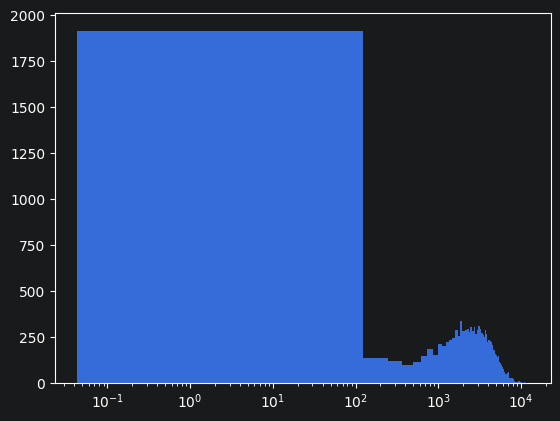

In [13]:
# test if different for both catalog combined
radius_hpic = nearest_neighbor_distances_units(hpic["ra"],hpic["dec"])
import matplotlib.pyplot as plt
plt.figure()
xs = [x for x in range(len(radius_hpic))]
plt.hist(radius_hpic,bins = 100)
plt.xscale('log')
plt.show()
# -> is more like slightly over 100

### mask catalog

I want to get hipc info and for stars not having it available get starcat info.
 so I am going to mask away all stars in starcat that have hipc info.
 then stack hpic together with the remaining stars from starcat.
 this means for the match function that cat 1 is hpic and cat 2 starcat.

In [5]:
# what does it mean for the radius, do I just take the rearest neighbor thing from starcat5 or do I need to reduce it?
# wait, the radius is supposed to be a float?

# match with starcat
mask_cat2_in_cat1 = get_mask_cat2_in_cat1(name_cat1 = hpic["simbad_name"],
                                          ra_cat1 = hpic["ra"],
                                          dec_cat1 = hpic["dec"],
                                          name_cat2 = starcat5["main_id"],
                                          ra_cat2 = starcat5["coo_ra"],
                                          dec_cat2 = starcat5["coo_dec"],
                                          r_arcsec = 50)

In [7]:
print(mask_cat2_in_cat1)
print(starcat5[mask_cat2_in_cat1])

[False  True  True ... False False  True]
            main_id                   coo_ra       ... stableHZ ecliptic_pm45deg
                                       deg         ...                          
------------------------------- ------------------ ... -------- ----------------
                     LP  137-54    252.89855562033 ...                     False
                    BD-06  4196 231.14805643667003 ...                      True
    Gaia DR3 654311849203736960 119.96106015912004 ...                      True
                    CD-42   594 25.732428526430834 ...                     False
                      L  103-27  182.9192437225883 ...                     False
                      HD 103799    179.31076368306 ...                      True
                 PM J16214-1223    245.36671642948 ...                      True
                     HD 107692B 185.68729944852916 ...                      True
                      HD  84117  145.5600675122075 ...             

#### unify column names

In [ ]:
# what do I call new column -> call them temp... before deciding, can change later

In [144]:
# unify null values
for col in new_colnames:
    print(pre_merge_hpic_masked[col])
    print(pre_merge_starcat_masked[col])

# sptype null vs empty -> do mask everywhere
# mass null vs mask
# rad null vs mask
# rad ref null vs empty
# i null vs mask
# binary 10 vs true false -> translate into true and false
# sep null vs mask
#mass st value nan -> can't find it again

        temp_main_id        
----------------------------
               TIC 459832522
               TIC 245873777
               TIC 272314138
               TIC 322899250
               TIC 368326352
               TIC 471011144
               TIC 280310048
               TIC 471011145
               TIC 157587146
               TIC 423088367
                         ...
GAIA DR3 6742328107524142976
GAIA DR3 6745573659695679616
GAIA DR3 6792808541781612800
GAIA DR3 6823750688771587840
GAIA DR3 6827751124390424320
GAIA DR3 6832480291404495360
GAIA DR3 6833291426043854976
GAIA DR3 6896057214818851712
GAIA DR3 6910053108781758976
GAIA DR3 6914073400035169536
Length = 12944 rows
          temp_main_id         
-------------------------------
                     LP  131-37
                    BD-07   699
                      L  349-68
                      HD  56609
                      HD  32564
                 PM J02570-1627
                      HD  67524
                      BPM

### analyze output catalog

In [15]:
print(catalog)

          temp_main_id             temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                       deg         ...                          
------------------------------- ------------------ ... -------- ----------------
                  TIC 459832522         213.915338 ...       --               --
                  TIC 245873777          68.980213 ...       --               --
                  TIC 272314138         187.791407 ...       --               --
                  TIC 322899250         101.286998 ...       --               --
                  TIC 368326352          79.172437 ...       --               --
                  TIC 471011144         219.903981 ...       --               --
                  TIC 280310048         114.825217 ...       --               --
                  TIC 471011145         219.910043 ...       --               --
                  TIC 157587146         279.234764 ...       --               --
                            

In [31]:
print(starcat5[float_colnames])
print(pre_merge_hpic_masked[temp_float_colnames])
print(catalog[temp_float_colnames])

plx_value    mag_i_value     ...   mass_st_value    sep_ang_value
   mas                       ...      solMass           arcsec   
--------- ------------------ ... ------------------ -------------
  20.5321                 -- ...                 --            --
  22.9986                 -- ...               0.64            --
  24.7695                 -- ... 0.7427057027816772            --
  34.9952                 -- ...                 --            --
  30.2143                 -- ...              0.162            --
  24.5639                 -- ...                 --            --
  27.1917                 -- ...                 --            --
  21.6884                 -- ...                 --            --
  21.0102                 -- ...                 --            --
      ...                ... ...                ...           ...
   89.734 11.199999809265137 ...              0.162           7.9
   27.539                 -- ...                 --           1.9
  27.6567 

### Refactored code

hm, looks like the stars in starcat5 that are not in HPIC are quite a lot (15'000) and also from spectral types that we did not expect (B to G as well) -> ask lia about it in the next meeting. first make some more plots
potential reasons
- hpic excluded object for some unknown reason
- matching does not work as it should and object is present in hpic
    - identifier changed -> should get covered by position match
    - coordinates not of same era -> should only be few years appart

In [1]:
import catalog.starcat5_merger.merger as merger
import importlib

In [5]:
importlib.reload(merger)

<module 'catalog.starcat5_merger.merger' from '/home/franziska/PycharmProjects/life_td/data_generation/life_td_data_generation/catalog/starcat5_merger/merger.py'>

radius:  103.43301245378981


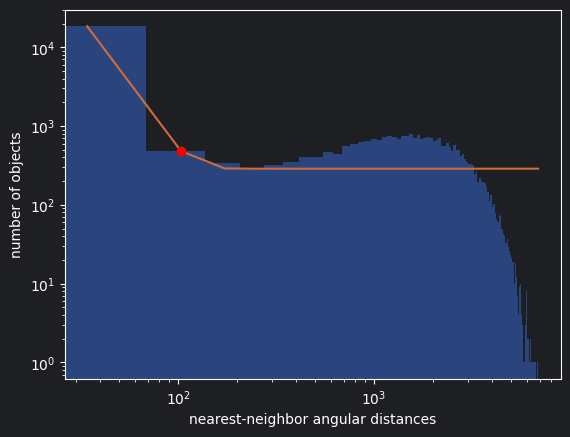

not in hpic 
  main_id        coo_ra        coo_dec   
                 deg            deg     
---------- --------------- -------------
LP  137-54 252.89855562033 51.6324558137
in hpic 
 main_id coo_ra coo_dec
         deg     deg  
------- ------ -------
        temp_main_id            temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                    deg         ...                          
---------------------------- ------------------ ... -------- ----------------
               TIC 459832522         213.915338 ...       --               --
               TIC 245873777          68.980213 ...       --               --
               TIC 272314138         187.791407 ...       --               --
               TIC 322899250         101.286998 ...       --               --
               TIC 368326352          79.172437 ...       --               --
               TIC 471011144         219.903981 ...       --               --
               TIC 280310048         114.

In [2]:
catalog, pre_merge_starcat, starcat5, pre_merge_hpic, float_colnames, starcat5_in_hpic = merger.hpic_merger()
# still something going wrong, LP  137-54 should be in the "is in hpic" sample not other.

['temp_main_id', 'temp_coo_ra', 'temp_coo_dec', 'temp_sptype_string', 'temp_plx_value', 'temp_dist_st_value', 'coo_gal_l', 'coo_gal_b', 'temp_teff_st_value', 'temp_teff_ref', 'temp_mass_st_value', 'temp_mass_ref', 'temp_radius_st_value', 'temp_radius_ref', 'temp_binary_flag', 'binary_ref', 'temp_mag_i_value', 'temp_mag_j_value', 'class_lum', 'class_temp', 'parent_main_id', 'temp_sep_ang_value', 'unresolved_binaries', 'ms_temp_class', 'ms_lum_class', 'mass_flag', 'higher_order_multiples', 'single_parent', 'trivial_binaries', 'sep_flag', 'sep_phys_value', 'requirement_flag', 'suitable_companions', 'stableHZ', 'ecliptic_pm45deg']
        temp_main_id            temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                    deg         ...                          
---------------------------- ------------------ ... -------- ----------------
Gaia DR3 5536411345052989184 113.02422391276501 ...                     False
            UCAC4 324-100764 257.70400202398287 ...  

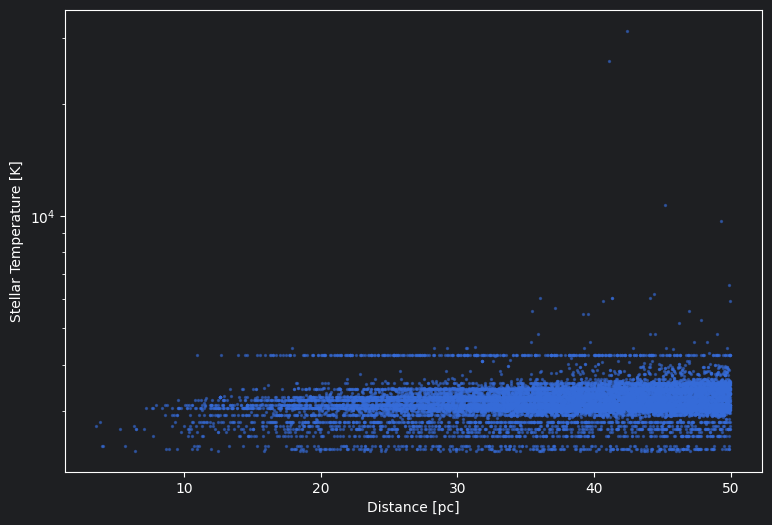

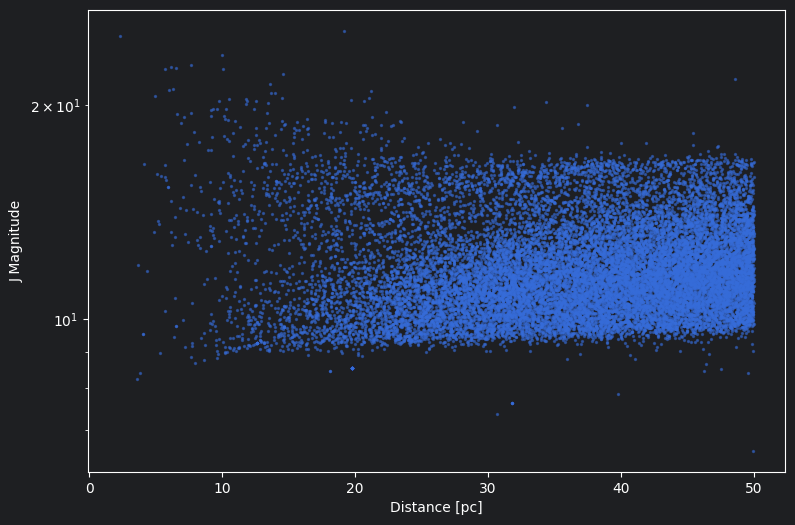

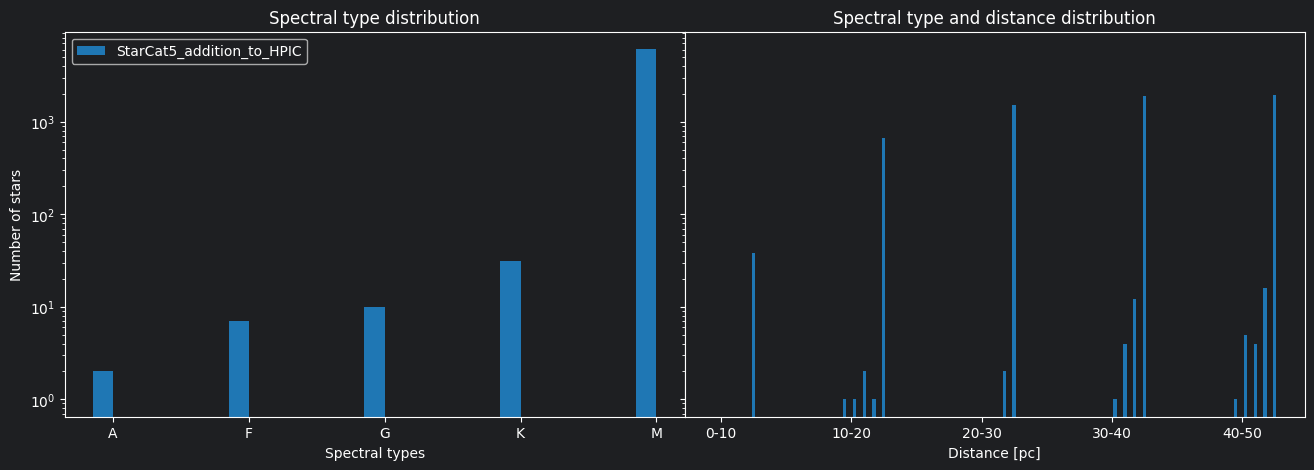

        temp_main_id            temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                    deg         ...                          
---------------------------- ------------------ ... -------- ----------------
Gaia DR3 5536411345052989184 113.02422391276501 ...                     False
            UCAC4 324-100764 257.70400202398287 ...                      True
                  LP  440-13    215.68085465661 ...                      True
Gaia DR3 5876213901845135488 228.40549924602038 ...                      True
Gaia DR3 5937772809085981568 250.97912242932495 ...                      True
     2MASS J15531086+6235447  238.2952662336612 ...                     False
                  LP  801-14 222.54971100010997 ...                      True
Gaia DR3 5998630021747026560 241.45753527587084 ...                      True
Gaia DR3 5898283058681727872 220.88219899071748 ...                      True
                         ...                ... ...      ...    

In [6]:
print(pre_merge_starcat.colnames)
print(pre_merge_starcat)
merger.analysis_starcat5_not_in_hpic(pre_merge_starcat) # wait, that is supposed to be stuff that is in hpic...

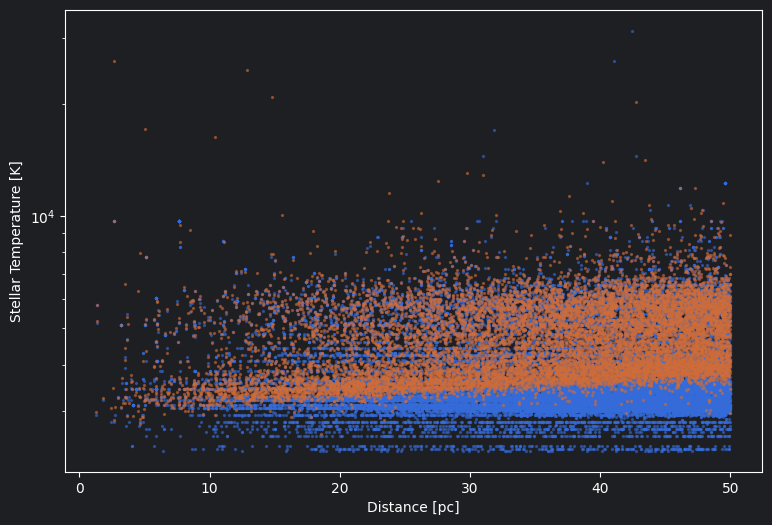

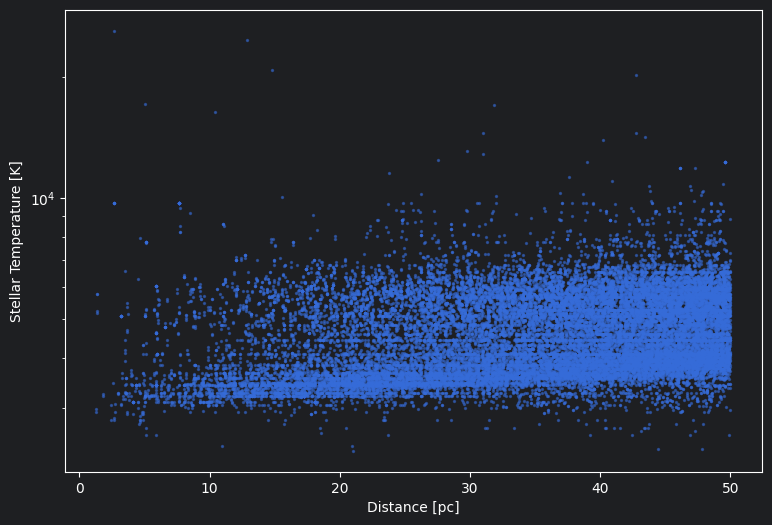

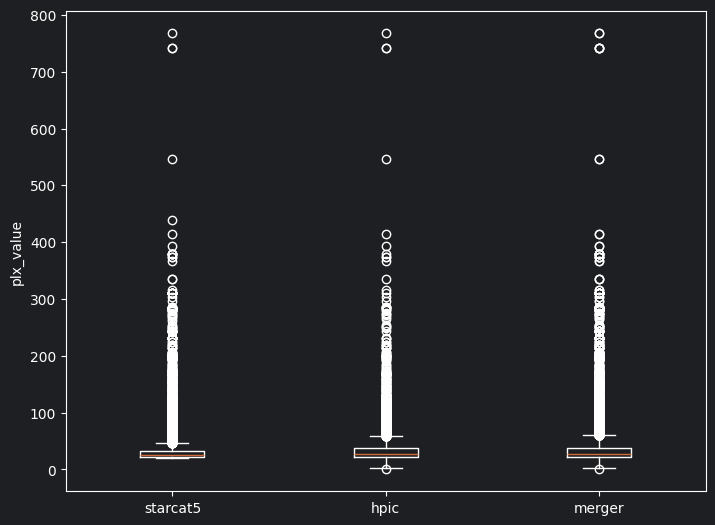

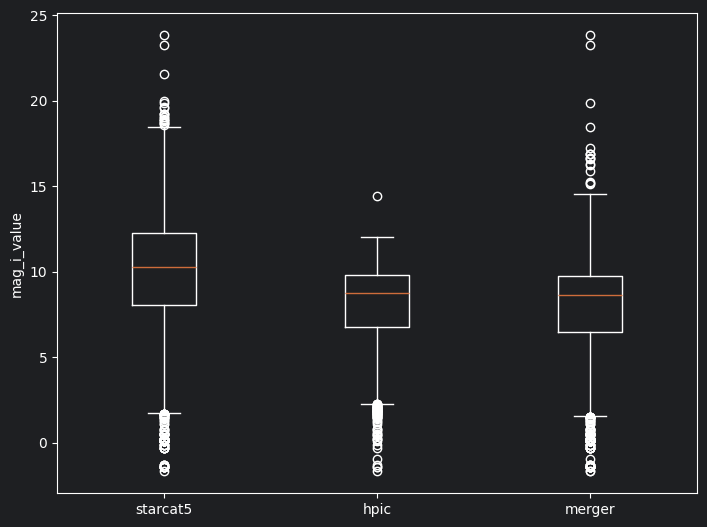

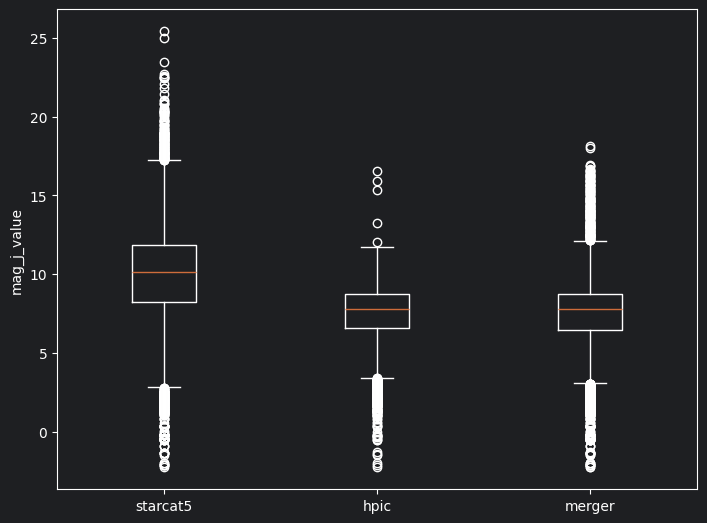

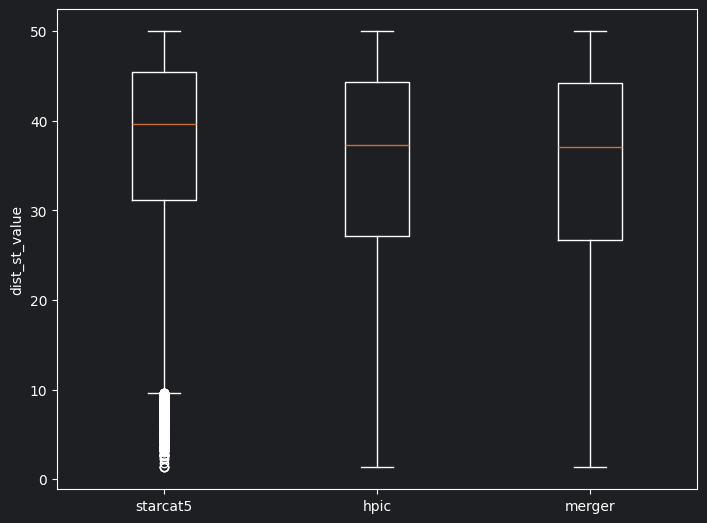

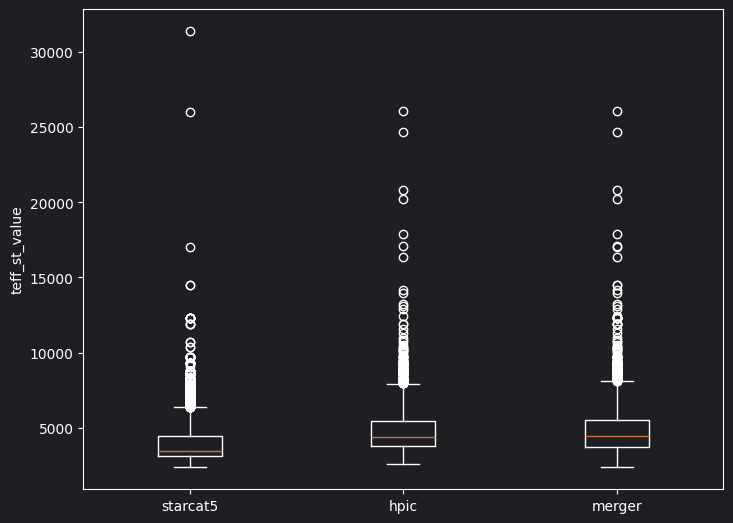

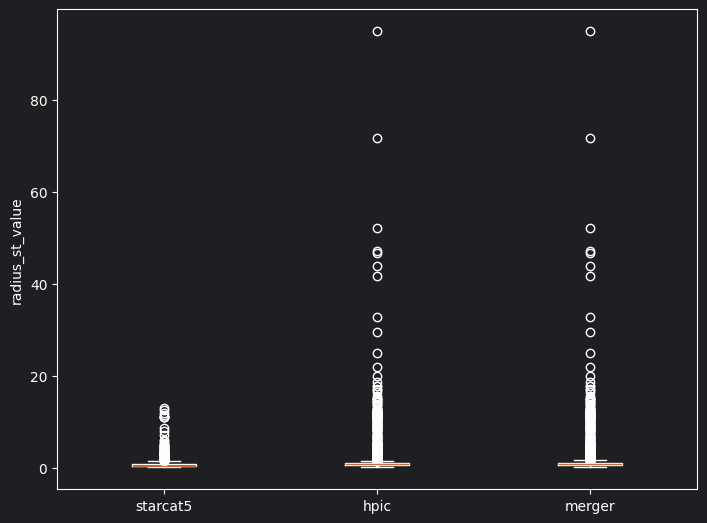

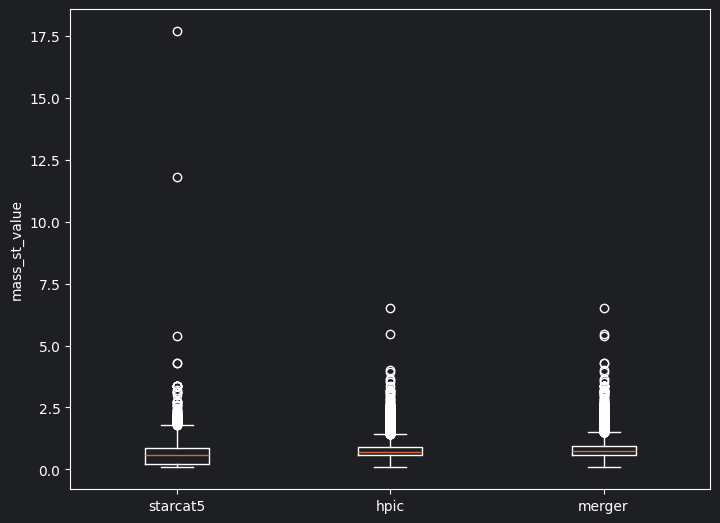

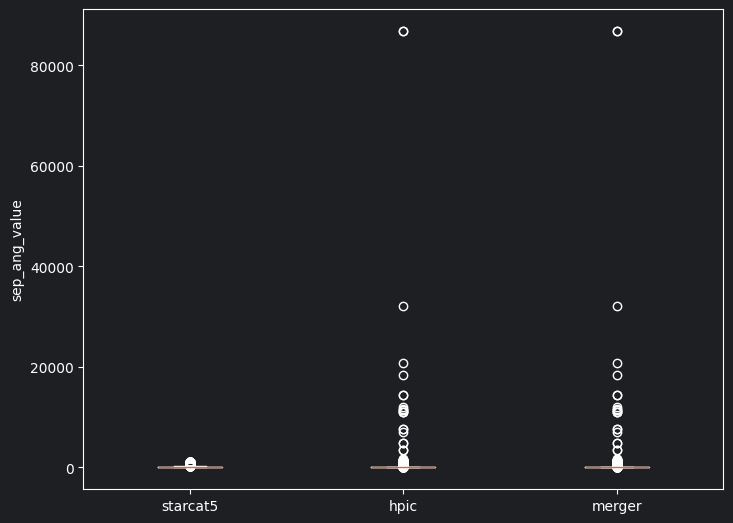

In [11]:
merger.merger_analysis(pre_merge_hpic, starcat5,catalog,float_colnames)

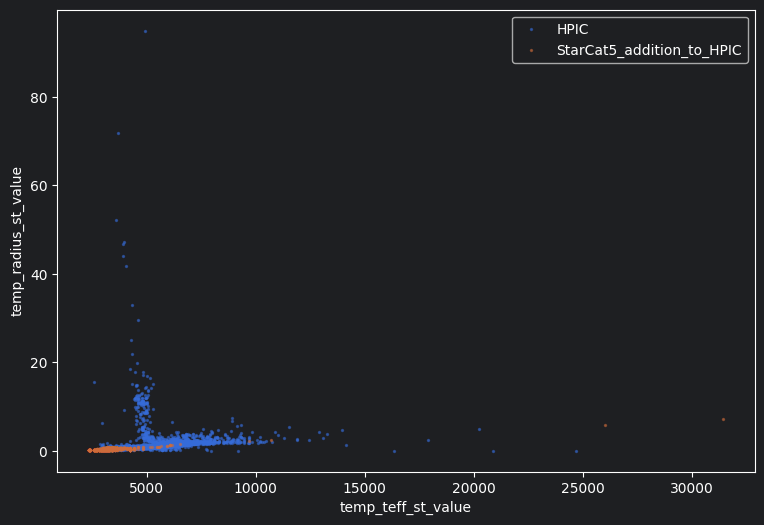

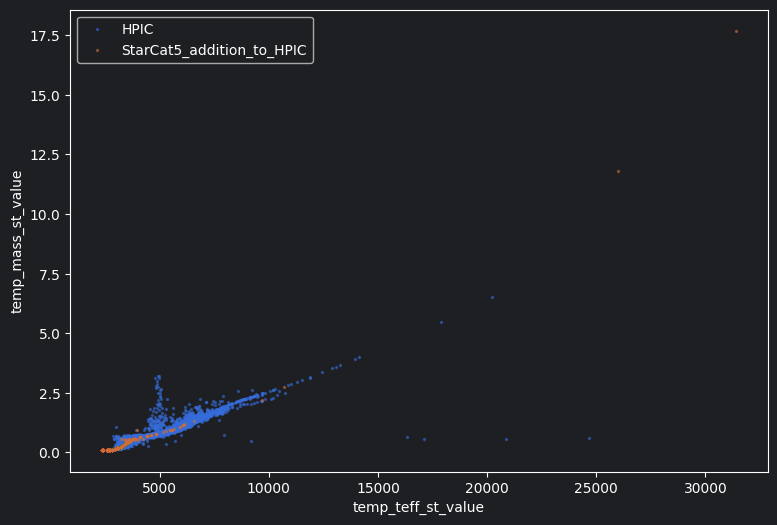

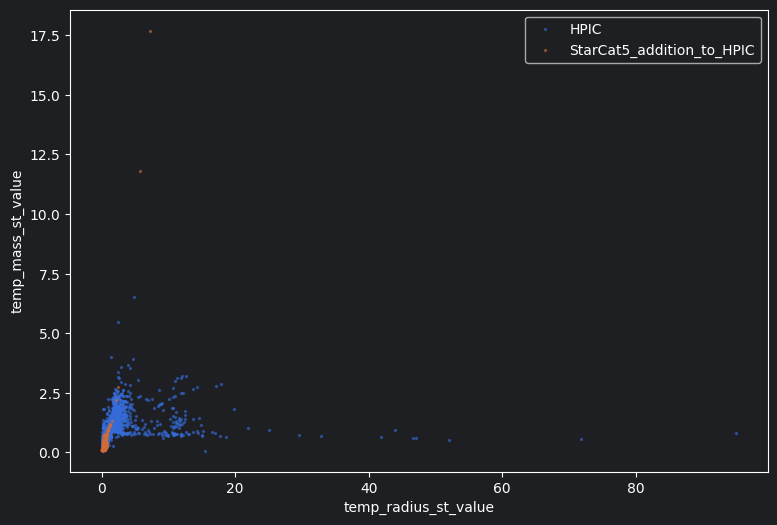

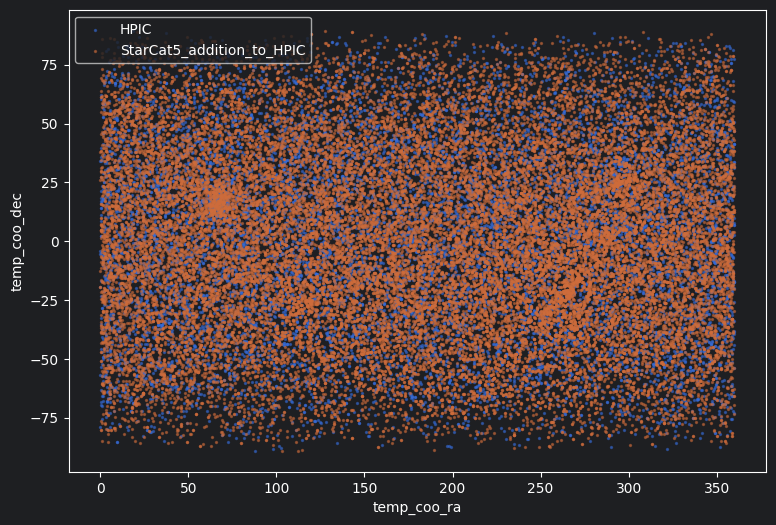

In [10]:
importlib.reload(merger)

merger.plot_para_vs_para(pre_merge_hpic,pre_merge_starcat)

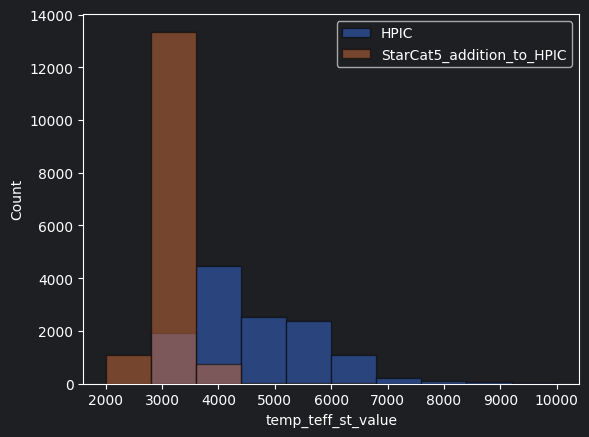

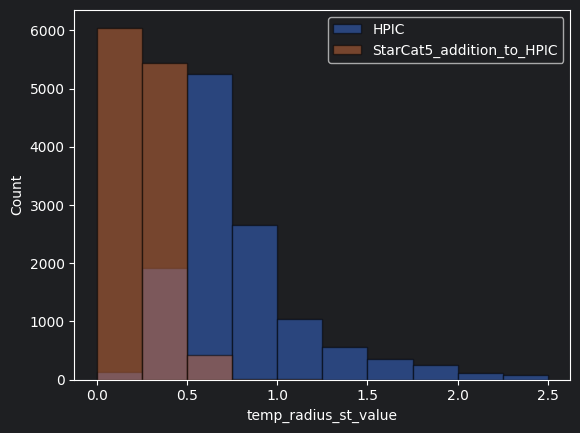

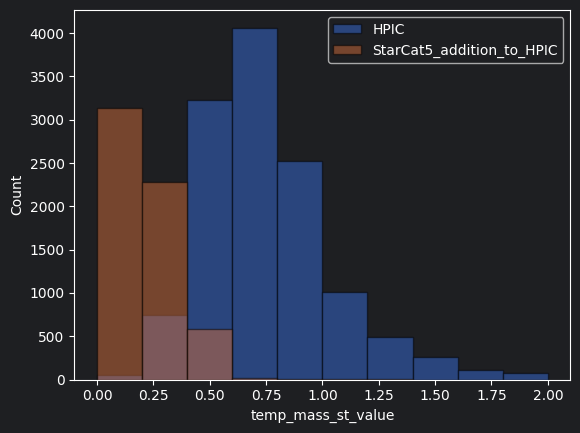

In [11]:
def hist_plot(pre_merge_hpic,masked_starcat5):
    alf = 0.5
    edgecol = "black"
    for col, range in zip(["temp_teff_st_value","temp_radius_st_value","temp_mass_st_value"],\
            [[2000,10000], [0,2.5], [0,2]]):
        plt.figure()
        plt.hist(pre_merge_hpic[col], alpha = alf, edgecolor = edgecol,
                 label = "HPIC", range = range)
        plt.hist(masked_starcat5[col], alpha = alf, edgecolor = edgecol,
                 label = "StarCat5_addition_to_HPIC", range = range)
        plt.legend()
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()
    return

hist_plot(pre_merge_hpic,pre_merge_starcat)
# how do I make the bins start at the same point? -> maybe range?
# how do I get edges -> edgecolors

In [12]:
import numpy as np


def spec_dist_plot(pre_merge_hpic):
    x = ["M0","M1","M2","M3","M4","M5","M6","M7","M8","M9"]
    spectype = np.array(pre_merge_hpic['temp_sptype_string'])
    for i in range(len(spectype)):
        spectype[i]=spectype[i][0:2]
    plt.figure()
    plt.hist(spectype)
    plt.xlabel("Spectral Subclass")
    plt.ylabel("Number of stars")
    plt.show()
    return

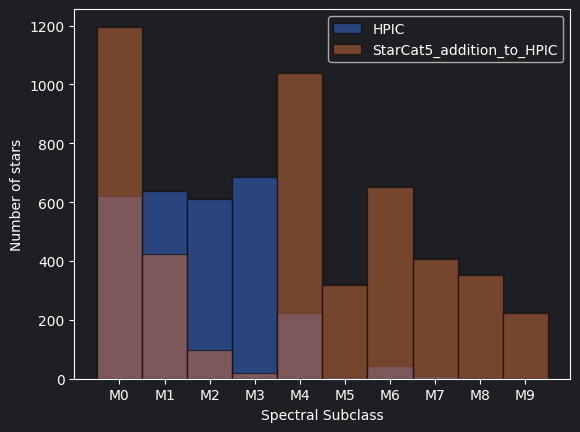

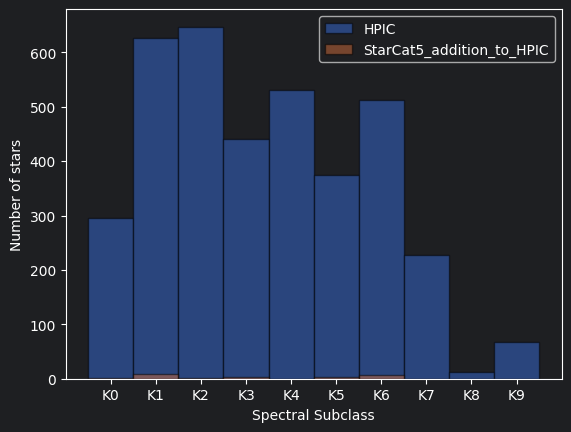

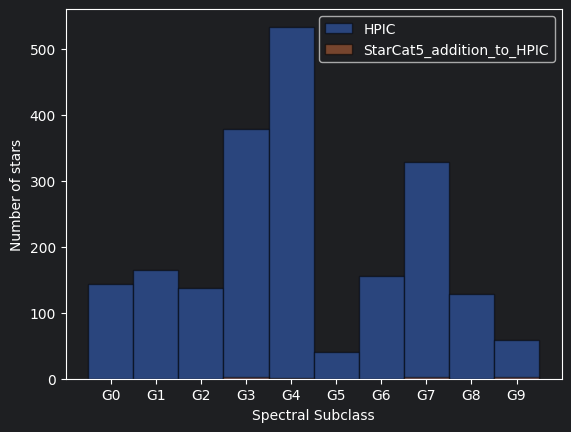

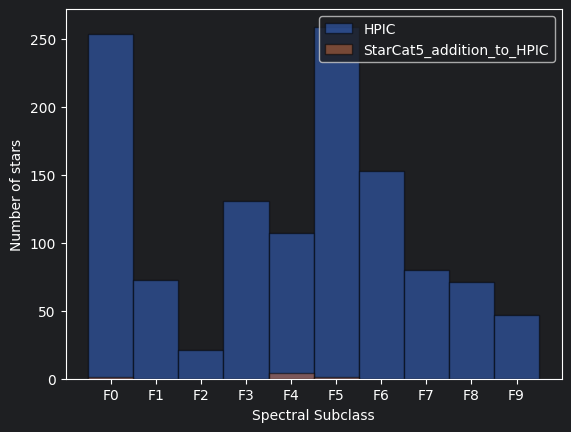

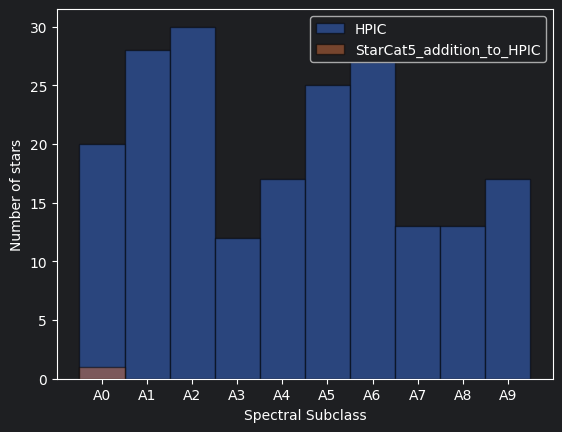

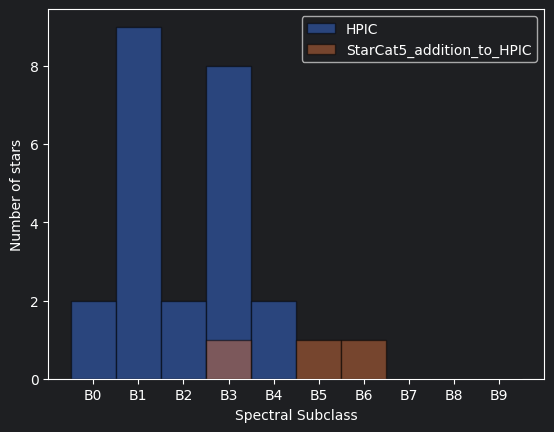

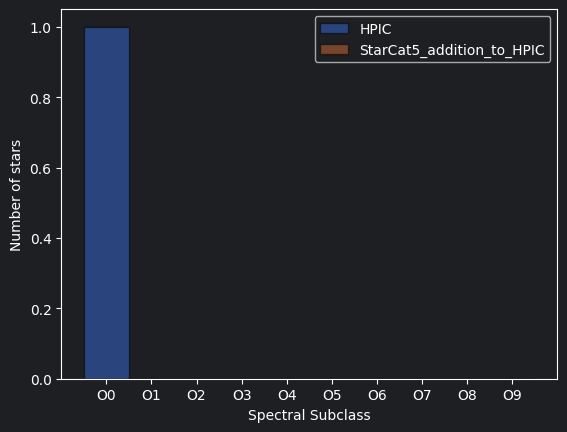

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def spec_dist_plot(catalogs,x):
    plt.figure()

    for cat,label in zip(catalogs,["HPIC","StarCat5_addition_to_HPIC"]):
        spectype = np.array(cat["temp_sptype_string"]).astype(str)

        # Reduce spectral types to first two characters, e.g. "M3.4" -> "M3"
        spectype = np.array([s[:2] for s in spectype])

        # Keep only spectral types listed in x
        spectype = spectype[np.isin(spectype, x)]


        plt.hist(spectype, bins=np.arange(len(x) + 1) - 0.5, edgecolor="black",label = label, alpha = 0.5)
    plt.xticks(range(len(x)), x)
    plt.xlabel("Spectral Subclass")
    plt.ylabel("Number of stars")
    plt.legend()

    plt.show()

    return

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["M0", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9"])

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["K0", "K1", "K2", "K3", "K4", "K5", "K6", "K7", "K8", "K9"])

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["G0", "G1", "G2", "G3", "G4", "G5", "G6", "G7", "G8", "G9"])

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["F0", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "F9"])

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["A0", "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9"])

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["B0", "B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9"])

spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["O0", "O1", "O2", "O3", "O4", "O5", "O6", "O7", "O8", "O9"])


In [3]:
print(catalog.colnames)

['temp_main_id', 'temp_coo_ra', 'temp_coo_dec', 'ra_J2016', 'dec_J2016', 'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'hip_name', 'tm_name', 'tyc_name', 'wds_designation', 'simbad_name', 'source_list_fl', 'sy_pmra', 'sy_pmraerr', 'sy_pmdec', 'sy_pmdecerr', 'sy_pmsrc', 'sy_pm_reflink', 'sy_ujmag', 'sy_ujmagerr', 'sy_ujmagsrc', 'sy_ujmag_reflink', 'sy_bmag', 'sy_bmagerr', 'sy_bmagsrc', 'sy_bmag_reflink', 'sy_vmag', 'sy_vmagerr', 'sy_vmagsrc', 'sy_vmag_reflink', 'sy_rcmag', 'sy_rcmagerr', 'sy_rcmagsrc', 'sy_rcmag_reflink', 'temp_mag_i_value', 'sy_icmagerr', 'sy_icmagsrc', 'sy_icmag_reflink', 'temp_mag_j_value', 'sy_jmagerr', 'sy_jmagsrc', 'sy_jmag_reflink', 'sy_hmag', 'sy_hmagerr', 'sy_hmagsrc', 'sy_hmag_reflink', 'sy_kmag', 'sy_kmagmerr', 'sy_kmagsrc', 'sy_kmag_reflink', 'sy_tmag', 'sy_tmagerr', 'sy_gaiamag', 'sy_gaiamagerr', 'sy_gaiamagsrc', 'sy_gaiamag_reflink', 'sy_bpmag', 'sy_bpmagerr', 'sy_rpmag', 'sy_rpmagerr', 'temp_plx_value', 'sy_plxerr', 'sy_plxsrc', 'sy_plx_reflink', 'temp_dist_st_

In [8]:
#* eta UMa is a B star that is flagged as not being in HPIC, foung gaia dr3 id and searching in HPIC starcat merger

import numpy as np
print(catalog['gaia_dr3_id'])
print(catalog['simbad_name','gaia_dr3_id','temp_coo_ra', 'temp_coo_dec'][np.where(catalog['gaia_dr3_id'] == "1510374147844219904")])
# found object that is said to not be in HPIC but actually is
# check if main_id starcat5_masked matches simbad_name catalog # they do -> made test -> found out need to take inverse of mask. run stuff again but got same issue
# check if coordinates matche
# check if starcat5_masked is correctly assigned and not an alias of catalog...

gaia_dr3_id
-----------
       null
       null
       null
       null
       null
       null
       null
       null
       null
       null
        ...
           
           
           
           
           
           
           
           
           
           
Length = 28819 rows
simbad_name     gaia_dr3_id       temp_coo_ra    temp_coo_dec 
                                      deg            deg      
----------- ------------------- --------------- --------------
  * eta UMa 1510374147844219904 206.88435898896 49.31320798716


In [9]:
# "HPIC_StarCat","starcat5_not_in_hpic","pre_merge_hpic"
import numpy as np

hpic_name = pre_merge_hpic['simbad_name'][np.where(pre_merge_hpic['gaia_dr3_id'] == "3345579721706291712")]
starcat_name = pre_merge_starcat['temp_main_id'][np.where(pre_merge_starcat['temp_main_id'] == "TYC 1313-276-1")] # LP  137-54
print(hpic_name,starcat_name, hpic_name == starcat_name)
# so names are identical meaning match function might have an issue -> create a unit test

simbad_name
-----------  temp_main_id 
--------------
TYC 1313-276-1 []


In [34]:
print(pre_merge_hpic['simbad_name','temp_coo_ra','temp_coo_dec'][np.where(pre_merge_hpic['simbad_name'] == "LP  137-54")])
print(starcat5_not_in_hpic['main_id','coo_ra','coo_dec'][np.where(starcat5_not_in_hpic['main_id'] == "LP  137-54")])


simbad_name   temp_coo_ra    temp_coo_dec 
----------- --------------- --------------
 LP  137-54 252.89855630184 51.63245588655
 main_id        coo_ra        coo_dec   
                 deg            deg     
---------- --------------- -------------
LP  137-54 252.89855562033 51.6324558137


## Input
try to query different archives outside of db context

In [3]:
from provider.utils import query

### Gaia

Notes: I could technically structurize it more (input parameters, output parameters,...) but don't think is useful at this point as not all sources will be via adql. better get list first, then write function for structuring.

In [1]:
adql_query = """
    SELECT s.source_id ,p.mass_flame, p.radius_flame,
        p.teff_gspphot, p.teff_gspspec, m.nss_solution_type, p.age_flame,
        p.teff_gspspec_lower, p.teff_gspspec_upper, p.flags_gspspec
    FROM gaiadr3.gaia_source as s
        JOIN gaiadr3.astrophysical_parameters as p ON s.source_id=p.source_id
            LEFT JOIN gaiadr3.nss_two_body_orbit as m ON s.source_id=m.source_id
    WHERE s.parallax >=30."""

gaia_helptab = query("https://gea.esac.esa.int/tap-server/tap", adql_query)

Service is UP and running.


In [2]:
print(gaia_helptab)

     source_id      mass_flame ...               flags_gspspec              
                     solMass   ...                                          
------------------- ---------- ... -----------------------------------------
    769456276704128         -- ...                                          
  56252256123908096         -- ...                                          
  60186343087140096  0.7181468 ... 00000000000001110009900001000999999999995
  73326018139806592         -- ... 00100111000009999999999999999999999999999
  78649033103283584         -- ...                                          
  98092934167683072         -- ...                                          
 115311458058061440  0.8797081 ... 00000000000001010000000109900990099999995
 115851902384016128         -- ...                                          
 126342377182577408         -- ...                                          
                ...        ... ...                                       ...

### HWO

In [ ]:
# spores see utils.analysis.create_other_catalogs
# same for HPIC
# so far both accessed via downloaded csv file. as they are not supposed to change often, I could keep it that way
# spores can be downloaded at https://sites.google.com/berkeley.edu/spores-hwo/science
# old saving location is Nebenproject/life_cat/data

## Reformatting

In [ ]:
# input table
# changes in column name
# changes in data e.g. unit


## Saving

In [ ]:
# input table (astropy? or pandas)
# output structure, so far

save(
    [table],
    ["name"],
    location="...",
)